# Task 1  —  Vectorize It

In [1]:
# 01 
prices = [10, 25, 40, 50, 60, 75, 80, 15, 30, 45,
          55, 65, 70, 90, 100, 20, 35, 48, 52, 85]
taxed_loop = []
for price in prices:
    taxed_loop.append(price * 1.08)
print(taxed_loop)

[10.8, 27.0, 43.2, 54.0, 64.80000000000001, 81.0, 86.4, 16.200000000000003, 32.400000000000006, 48.6, 59.400000000000006, 70.2, 75.60000000000001, 97.2, 108.0, 21.6, 37.800000000000004, 51.84, 56.160000000000004, 91.80000000000001]


In [2]:
# 02
import numpy as np
prices_array = np.array(prices)
taxed_numpy = prices_array * 1.08
print(taxed_numpy)

[ 10.8   27.    43.2   54.    64.8   81.    86.4   16.2   32.4   48.6
  59.4   70.2   75.6   97.2  108.    21.6   37.8   51.84  56.16  91.8 ]


In [3]:
# 03
above_50 = taxed_numpy[taxed_numpy > 50]
print(above_50)

[ 54.    64.8   81.    86.4   59.4   70.2   75.6   97.2  108.    51.84
  56.16  91.8 ]


In [4]:
# 04 
above_50 = taxed_numpy[taxed_numpy > 50]
print(above_50)
print(np.allclose(taxed_loop, taxed_numpy))

[ 54.    64.8   81.    86.4   59.4   70.2   75.6   97.2  108.    51.84
  56.16  91.8 ]
True


# Task 2  —  Load & Explore

In [5]:
# 01 - create a csv file
import pandas as pd
data = {
    "name": [
        "Anu", "Ardra", "Ritika", "Sandy", "Deepu",
        "Manju", "Lekhya", "Keerthi", "Lalli", "Mj",
        "Tony", "Leo", "Hedwig", "Noah", "Max"
    ],
    "department": [
        "IT", "HR", "Sales", "IT", "Finance",
        "Sales", "IT", "HR", "Finance", "Sales",
        "IT", "Finance", "HR", "Sales", "IT"
    ],
    "salary": [
        60000, 45000, 50000, 70000, 65000,
        55000, 75000, 48000, 62000, 58000,
        80000, 68000, 52000, 60000, 72000
    ],
    "years_experience": [
        2, 3, 4, 5, 6,
        3, 7, 4, 5, 4,
        8, 6, 3, 5, 7
    ]
}
df = pd.DataFrame(data)
df.to_csv("employees.csv", index=False)
print("CSV file created!")

CSV file created!


In [6]:
# 02 read the file 
df = pd.read_csv("employees.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   name              15 non-null     object
 1   department        15 non-null     object
 2   salary            15 non-null     int64 
 3   years_experience  15 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 612.0+ bytes
None
             salary  years_experience
count     15.000000         15.000000
mean   61333.333333          4.800000
std    10341.778423          1.740279
min    45000.000000          2.000000
25%    53500.000000          3.500000
50%    60000.000000          5.000000
75%    69000.000000          6.000000
max    80000.000000          8.000000


In [9]:
# 03 group 
summary = df.groupby("department").agg(
    average_salary=("salary", "mean"),
    headcount=("name", "count")
)
print(summary)

            average_salary  headcount
department                           
Finance       65000.000000          3
HR            48333.333333          3
IT            71400.000000          5
Sales         55750.000000          4


In [10]:
# 04 sort the grouped result
summary = summary.sort_values("average_salary", ascending=False)
print(summary)

            average_salary  headcount
department                           
IT            71400.000000          5
Finance       65000.000000          3
Sales         55750.000000          4
HR            48333.333333          3


# Task 3  —  Join the Data

In [11]:
# 01 
import pandas as pd
import numpy as np
departments = pd.DataFrame({
    "department": ["IT", "HR", "Sales", "Finance"],
    "department_budget": [500000, 300000, 400000, 450000]
})
inner_join = pd.merge(
    df,
    departments,
    on="department",
    how="inner"
)
print(inner_join)

       name department  salary  years_experience  department_budget
0       Anu         IT   60000                 2             500000
1     Ardra         HR   45000                 3             300000
2    Ritika      Sales   50000                 4             400000
3     Sandy         IT   70000                 5             500000
4     Deepu    Finance   65000                 6             450000
5     Manju      Sales   55000                 3             400000
6    Lekhya         IT   75000                 7             500000
7   Keerthi         HR   48000                 4             300000
8     Lalli    Finance   62000                 5             450000
9        Mj      Sales   58000                 4             400000
10     Tony         IT   80000                 8             500000
11      Leo    Finance   68000                 6             450000
12   Hedwig         HR   52000                 3             300000
13     Noah      Sales   60000                 5

In [12]:
# 02
new_employee = pd.DataFrame({
    "name": ["Peter"],
    "department": ["Marketing"],
    "salary": [55000],
    "years_experience": [4]
})
df2 = pd.concat([df, new_employee], ignore_index=True)
left_join = pd.merge(
    df2,
    departments,
    on="department",
    how="left"
)
print(left_join)

       name department  salary  years_experience  department_budget
0       Anu         IT   60000                 2           500000.0
1     Ardra         HR   45000                 3           300000.0
2    Ritika      Sales   50000                 4           400000.0
3     Sandy         IT   70000                 5           500000.0
4     Deepu    Finance   65000                 6           450000.0
5     Manju      Sales   55000                 3           400000.0
6    Lekhya         IT   75000                 7           500000.0
7   Keerthi         HR   48000                 4           300000.0
8     Lalli    Finance   62000                 5           450000.0
9        Mj      Sales   58000                 4           400000.0
10     Tony         IT   80000                 8           500000.0
11      Leo    Finance   68000                 6           450000.0
12   Hedwig         HR   52000                 3           300000.0
13     Noah      Sales   60000                 5

In [13]:
# 03
df2.loc[0, "salary"] = np.nan
df2.loc[1, "salary"] = np.nan
print(df2.isna().sum())

name                0
department          0
salary              2
years_experience    0
dtype: int64


In [14]:
# Fill missing salaries with the average salary because this keeps all employees in the dataset while using a reasonable typical value.
df2["salary"] = df2["salary"].fillna(df2["salary"].mean())
print(df2)

       name department        salary  years_experience
0       Anu         IT  62142.857143                 2
1     Ardra         HR  62142.857143                 3
2    Ritika      Sales  50000.000000                 4
3     Sandy         IT  70000.000000                 5
4     Deepu    Finance  65000.000000                 6
5     Manju      Sales  55000.000000                 3
6    Lekhya         IT  75000.000000                 7
7   Keerthi         HR  48000.000000                 4
8     Lalli    Finance  62000.000000                 5
9        Mj      Sales  58000.000000                 4
10     Tony         IT  80000.000000                 8
11      Leo    Finance  68000.000000                 6
12   Hedwig         HR  52000.000000                 3
13     Noah      Sales  60000.000000                 5
14      Max         IT  72000.000000                 7
15    Peter  Marketing  55000.000000                 4


# Task 4  —  Tell a Story

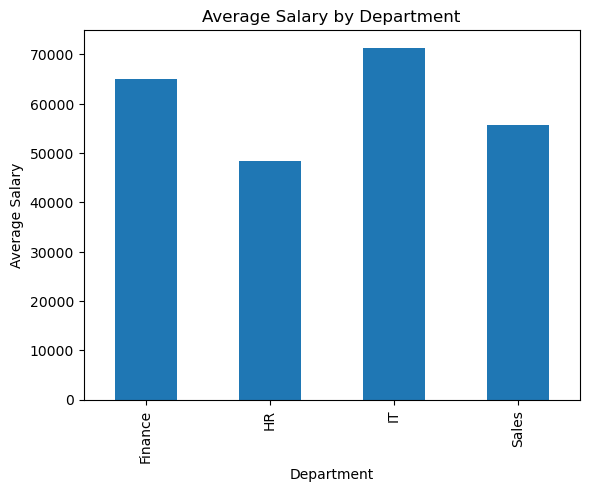

In [15]:
# 01
import matplotlib.pyplot as plt
avg_salary = df.groupby("department")["salary"].mean()
avg_salary.plot(kind="bar")
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

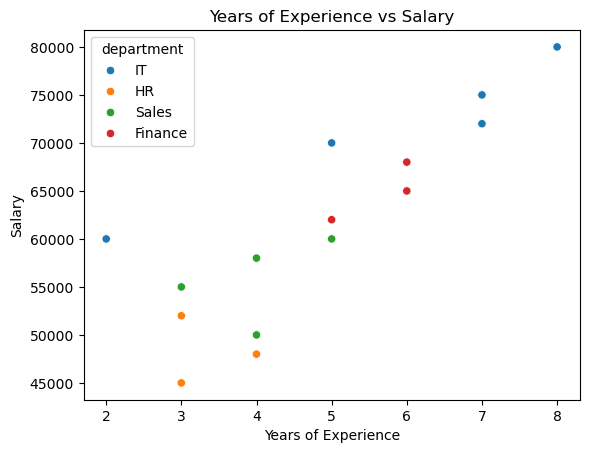

In [16]:
# 02
import seaborn as sns
sns.scatterplot(
    data=df,
    x="years_experience",
    y="salary",
    hue="department"
)
plt.title("Years of Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

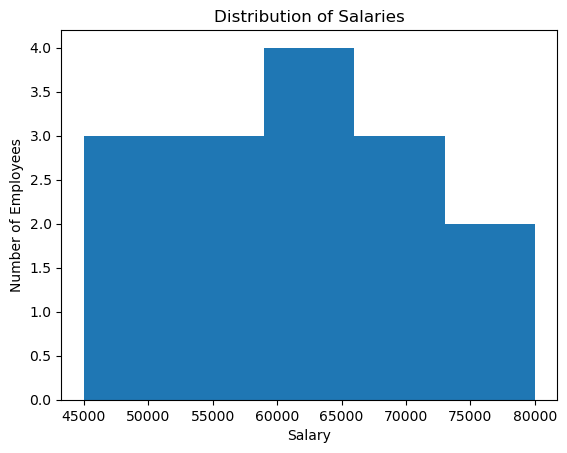

In [17]:
# 03
plt.hist(df["salary"], bins=5)
plt.title("Distribution of Salaries")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.show()

In [18]:
# 04
print("Bar chart: It compares average salaries between departments.")
print("Scatter plot: It shows the relationship between experience and salary.")
print("Histogram: It shows how salaries are distributed across all employees.")

Bar chart: It compares average salaries between departments.
Scatter plot: It shows the relationship between experience and salary.
Histogram: It shows how salaries are distributed across all employees.


# Task 05 - consolidation reflection

# Task 6  —  Readiness Self-Check

In [19]:
# 01
class TrainingRun:
    def __init__(self, model_name, learning_rate):
        self.model_name = model_name
        self.learning_rate = learning_rate

    def __str__(self):
        return f"TrainingRun(model='{self.model_name}', lr={self.learning_rate})"